## 학습 목표
- CNN 구조 설계부터 실험까지 end-to-end 경험
- Feature Extractor와 Classifier 분리 설계
- Conv/Pool/ReLU 조합과 파라미터 계산
- Hook을 활용한 레이어 출력 shape 추적
- 하이퍼파라미터 튜닝 경험

## 데이터셋: SVHN (Street View House Numbers)
- Google Street View에서 수집한 집 번호 이미지
- 10개 클래스 (숫자 0-9)
- 32×32 컬러 이미지
- 학습: 73,257개, 테스트: 26,032개

In [1]:
!sudo apt-get install locales -qq

# 2. 한국어 (ko_KR.UTF-8) locale 생성
# 이 단계에서 오류가 나지 않아야 해요!
!sudo locale-gen ko_KR.UTF-8

# 3. 환경 변수 설정
# 파이썬 코드 안에서 실행합니다.
import os
os.environ['LANG'] = 'ko_KR.UTF-8'
os.environ['LC_ALL'] = 'ko_KR.UTF-8'
os.environ['LC_CTYPE'] = 'ko_KR.UTF-8'
os.environ['LANGUAGE'] = 'ko_KR.UTF-8'

Generating locales (this might take a while)...
  ko_KR.UTF-8... done
Generation complete.


런타임 다시 시작

In [1]:
# 나눔 폰트 설치 (Colab에서 한글 표시를 위해 가장 많이 사용돼요)
!sudo apt-get install -y fonts-nanum > /dev/null 2>&1
!sudo fc-cache -fv > /dev/null 2>&1

# Matplotlib 등에서 한글 폰트 설정을 위한 코드 (streamlit과는 직접 관련 없을 수도 있지만,
# 만약을 위해 환경 준비 차원에서 실행해주세요)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 설치된 폰트 경로 확인
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 예시
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    print("한글 폰트 설정 완료: NanumBarunGothic")
else:
    print(f"Warning: 폰트 파일이 없습니다: {font_path}")

# (선택 사항) 시스템에 설치된 폰트 목록 확인
# [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]

한글 폰트 설정 완료: NanumBarunGothic


In [2]:
# PyTorch 및 관련 라이브러리 임포트
import torch  # PyTorch 메인 라이브러리
import torch.nn as nn  # 신경망 모듈 (레이어, 손실함수 등)
import torch.optim as optim  # 최적화 알고리즘 (Adam, SGD 등)
import torch.nn.functional as F  # 활성화 함수, Softmax 등
from torch.utils.data import DataLoader  # 데이터 로더 (배치 처리)

# torchvision: 컴퓨터 비전 관련 유틸리티
import torchvision  # 비전 관련 전체 모듈
import torchvision.transforms as transforms  # 이미지 전처리 및 증강
from torchvision import datasets  # SVHN, CIFAR 등 표준 데이터셋

# 데이터 처리 및 시각화
import numpy as np  # 수치 연산 라이브러리
import matplotlib.pyplot as plt  # 그래프 및 이미지 시각화
from collections import OrderedDict  # 순서가 보장되는 딕셔너리

# 진행 상황 표시 (선택사항)
from tqdm import tqdm  # 진행률 표시줄 (progress bar)

# GPU 사용 가능 여부 확인 및 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# torch.cuda.is_available(): CUDA(GPU)가 사용 가능한지 확인
# GPU 있으면 'cuda', 없으면 'cpu' 사용
print(f'사용 디바이스: {device}')

# 재현성을 위한 시드 고정
torch.manual_seed(42)  # PyTorch 난수 시드 고정
np.random.seed(42)  # NumPy 난수 시드 고정
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)  # CUDA 난수 시드 고정
    torch.backends.cudnn.deterministic = True  # 결정적 알고리즘 사용
    torch.backends.cudnn.benchmark = False  # 벤치마크 비활성화 (재현성 우선)

print('환경 설정 완료!')
print(f'PyTorch 버전: {torch.__version__}')
print(f'Torchvision 버전: {torchvision.__version__}')

사용 디바이스: cuda
환경 설정 완료!
PyTorch 버전: 2.11.0+cu128
Torchvision 버전: 0.26.0+cu128


In [3]:
transform_train = transforms.Compose([
    # RandomCrop: 이미지를 32x32 크기로 랜덤하게 크롭하되, 4픽셀 패딩 추가
    # 패딩으로 36x36이 되고, 여기서 32x32를 랜덤 위치에서 자름 (위치 변화)
    transforms.RandomCrop(32, padding=4),

    # RandomHorizontalFlip: 50% 확률로 이미지를 좌우 반전
    # 숫자 이미지에서 좌우 대칭은 의미가 있을 수 있음 (예: 6과 9는 다르지만)
    transforms.RandomHorizontalFlip(p=0.5),

    # ColorJitter: 밝기, 대비, 채도를 랜덤하게 변경 (조명 조건 변화 시뮬레이션)
    # brightness: 밝기를 ±20% 변경
    # contrast: 대비를 ±20% 변경
    # saturation: 채도를 ±20% 변경
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

    # ToTensor: PIL Image를 PyTorch Tensor로 변환
    # (H, W, C) -> (C, H, W) 형태로 변경
    # 픽셀 값을 [0, 255] -> [0.0, 1.0] 범위로 정규화
    transforms.ToTensor(),

    # Normalize: 각 채널을 평균 0.5, 표준편차 0.5로 정규화
    # 실제로는 [0, 1] -> [-1, 1] 범위로 변환하는 효과
    # 공식: normalized = (pixel - mean) / std
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# 테스트용 전처리 (증강 없음)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))

])



In [4]:
from re import split
from logging import root

train_dataset = datasets.SVHN(
    root='./data',
    split='train',
    download=True,
    transform=transform_train
)

test_dataset = datasets.SVHN(
    root='./data',
    split='test',
    download=True,
    transform=transform_test
)

100%|██████████| 182M/182M [00:22<00:00, 8.17MB/s]
100%|██████████| 64.3M/64.3M [00:14<00:00, 4.57MB/s]


In [5]:
# 데이터 로더 생성

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

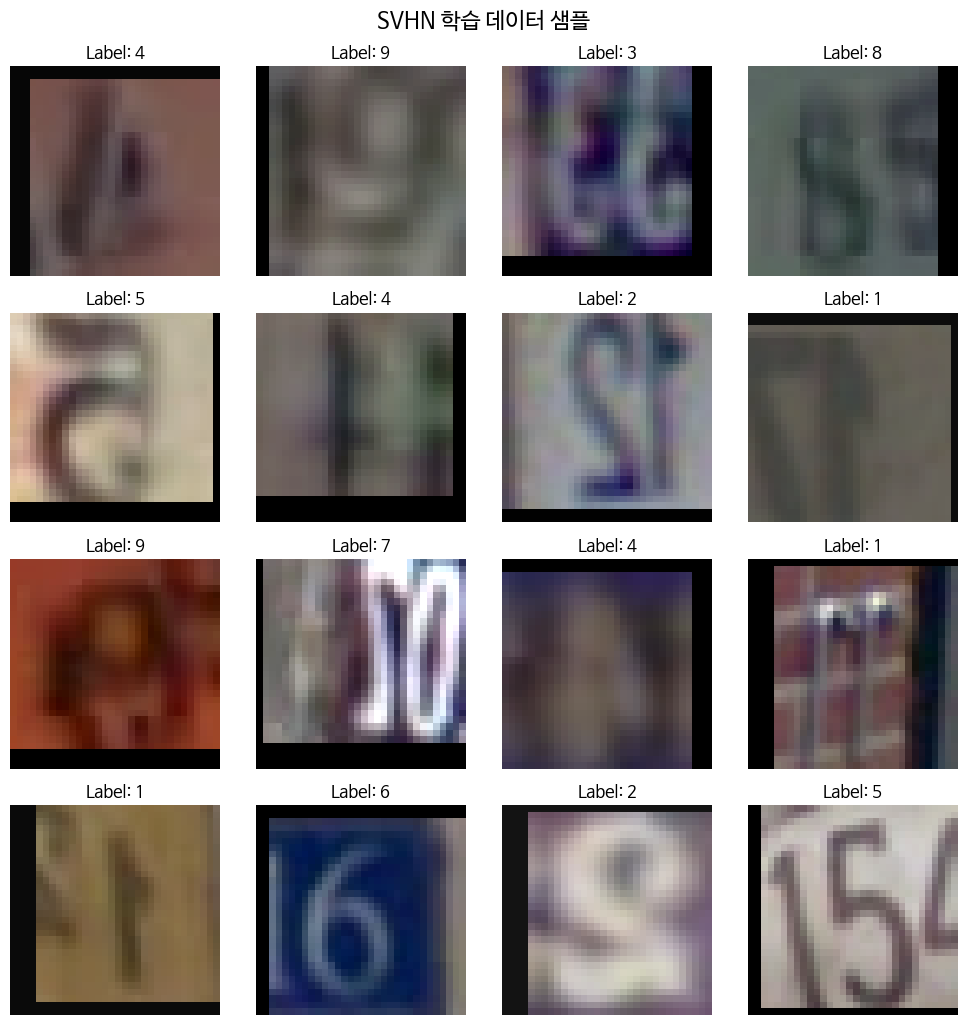

In [6]:
# 샘플 이미지 시각화
# 왜 해요? 데이터 셋이 제대로 로드되었는지 확인할려고 한다.

class_names = ['0','1','2','3','4','5','6','7','8','9']

images, labels = next(iter(train_loader))

def denormalize(tensor):
    return tensor * 0.5 + 0.5
    # 정규화 역변환: pixel = (normlized * std) + mean

# 16개 이미지를 4x4 그리드로 시각화
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)  # 4x4 그리드의 i+1번째 위치

    # 이미지를 (C, H, W) -> (H, W, C) 형태로 변환
    img = denormalize(images[i]).cpu().numpy().transpose(1, 2, 0)

    # 이미지 표시
    plt.imshow(img)
    plt.title(f'Label: {class_names[labels[i]]}')  # 레이블 표시
    plt.axis('off')  # 축 숨기기

plt.tight_layout()  # 레이아웃 자동 조정
plt.suptitle('SVHN 학습 데이터 샘플', y=1.02, fontsize=16)
plt.show()


CNN 모델 정의

In [7]:
class SVHN_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SVHN_CNN, self).__init__()
        # feature extraction(특징 추출)
        # Conv2d block 1 : input_channel (3) rgb >> 32 output_channel
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,
                               kernel_size=3, stride=1, padding=1)
                            # out_channels=32 (출력 채널 수: 필터 개수)
        # 파라미터 수 : (3*3*3+1)*32 = 896
        # 출력크기 [batch_size, 32, 32, 32]

        # MaxPool1 : 공간해상도 절반 축소
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 2*2 영역에서 최대값 추출, 2칸씩 이동

        # 출력크기 [batch_size, 32, 16, 16]

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64,
                               kernel_size=3, stride=1, padding=1)
        # 파라미터 수 (3*3*32+1) * 64 = 18,496
        # 출력크기 [batch_size, 64, 16, 16]
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 출력크기 [batch_size, 64, 8, 8]

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128,
                               kernel_size=3, stride=1, padding=1)
        # 파라미터 수 (3*3*64+1) * 128 = 73,856
        # 출력크기 [batch_size, 128, 8, 8]
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 출력크기 [batch_size, 128, 4, 4]

        # classifier (분류기)
        # fc (fully connected 완전 연결층)
        # 추출된 특징 >> 최종 분류
        self.fc1 = nn.Linear(in_features=128*4*4, out_features=512)
        # 파라미터 수 : (2048 + 1) * 512 = 1,049,088

        # Dropout : 과적합 방지(학습시 50% 랜덤 비활성화)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=512, out_features=num_classes)
        # 파라미터 수 (512 + 1) * 10 = 5,130

    def forward(self, x):
        # feature extraction
        # Conv Block 1
        x = self.conv1(x)       # [batch, 3, 32, 32] >> [batch, 32, 32, 32]
        x = F.relu(x)
        x= self.pool1(x)        # [batch, 32, 32, 32] >> [batch, 32,16, 16]

        # Conv Block 2
        x = self.conv2(x)       # [batch, 32,16, 16] >> [batch, 64, 16, 16]
        x = F.relu(x)
        x= self.pool2(x)        # [batch, 64,16, 16] >> [batch, 64, 8, 8]

        # Conv Block 3
        x = self.conv3(x)       # [batch, 64, 8, 8] >> [batch, 128, 8, 8]
        x = F.relu(x)
        x= self.pool3(x)        # [batch, 128, 8, 8] >> [batch, 128, 4, 4]

        # classifier (분류기)
        # flatten (1차원으로 펼쳐줌)
        x = x.view(x.size(0), -1) # [batch, 128, 4, 4] >> [batch, 128 * 4 * 4]
        # x.size(0) batch_size, -1 : 나머지 차원을 자동 계산해줘 128 * 4 * 4 = 2048

        # fully connected layer 1
        x = self.fc1(x)           # [batch, 2048] >> [batch, 512]
        x = F.relu(x)
        x = self.dropout(x)       # dropout 적용(학습시에만 적용)

        # fully connected layer 2 (출력층)
        x = self.fc2(x)           # [batch, 512] >> [batch, 10]

        return x

In [8]:
model = SVHN_CNN(num_classes=10) # 10개 클래스(0-9)
model = model.to(device)

In [9]:
model

SVHN_CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

In [10]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total

# count_parameters(model)
total_params = count_parameters(model)
print(f'모델 총 파라미터 수 : {total_params:,} 개')

모델 총 파라미터 수 : 1,147,466 개


Hook 사용한 레이어 출력 shape 추적

In [15]:
model.named_modules()

<generator object Module.named_modules at 0x7aaa2891b450>

In [14]:
model.__class__.__name__

'SVHN_CNN'

In [11]:
# hook : 모델의 중간 레이어 출력을 가로채는 매커니즘

# layer 별 출력 저장
layer_outputs = OrderedDict() # cf. {}

def register_hooks(model):
    handles = []

    def hook_fn(module, input, output):
    # module : 현재 실행 중인 레이어 객체, input: layer 입력, output layer 출력
        layer_name = module.__class__.__name__
        # 클래스 이름을 사용, 레이어 이름 추출
        # 예) Conv2d, ReLU, MaxPool2d

        # 동일한 layer type 이 여러 개 있을 경우, 번호 추가
        # 중복된 이름 처리
        # 예) Conv2d 이미 2개 있으면 count=2
        count = sum(1 for k in layer_outputs.keys() if layer_name in k)
        if count > 0 :
            layer_name = f'{layer_name}_{count+1}'
            # Conv2d_3

        layer_outputs[layer_name] = output.shape
        # 출력 크기를 딕셔너리에 저장

    # 중복이름 처리 1번째 만나는 Con2d >> Con2d, 2번째 만나는 Con2d >> Con2D_2 ..


    # 모든 하위 모듈(모든 레이어)에 hook 등록
    for name, module in model.named_modules():
        # 전체 모델 자체는 제외 (하위 레이어만 등록)
        if len(list(module.children())) == 0 and module != model:
            # len(list(module.children())) == 0 자식이 없는 레이어
            # Conv2d, MaxPool2d 개별로 등록

            handle = module.register_forward_hook(hook_fn)
            # register_forward_hook : 데이터가 레이어 통과 시 hook_fn 실행해라
            handles.append(handle)

    return handles

# hook 등록
hook_handles = register_hooks(model)
print(len(hook_handles))  #9

# 더미입력 순전파 실행 (hook trigger hook 발생유도)
# 입력 [배치=1, 채널=3, 높이=32, 너비=32]

dummy_input = torch.randn(1,3,32,32).to(device)

with torch.no_grad():
    output = model(dummy_input)

# print(output)
# tensor([[-0.0171, -0.0212,  0.0136,  0.0188, -0.0602,  0.0215,  0.0366,  0.1064,
        #  -0.0219, -0.0834]], device='cuda:0'
for layer_name, shape in layer_outputs.items():
    print(f'{layer_name:<25} {str(tuple(shape)):>30}')
    # layer name output's shape


# hook 제거 (메모리 정리)
for handle in hook_handles:
    handle.remove()


9
Conv2d                                   (1, 32, 32, 32)
MaxPool2d                                (1, 32, 16, 16)
Conv2d_2                                 (1, 64, 16, 16)
MaxPool2d_2                                (1, 64, 8, 8)
Conv2d_3                                  (1, 128, 8, 8)
MaxPool2d_3                               (1, 128, 4, 4)
Linear                                          (1, 512)
Dropout                                         (1, 512)
Linear_2                                         (1, 10)


학습 함수 정의

In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0 # epoch(학습) 전체 손실 누적
    correct = 0        # 맞춘 샘플 수
    total = 0          # 전체 샘플 수

    pbar = tqdm(train_loader, desc='학습중이예요', leave=False)
    # leave=False 학습이 끝나면 진행 바 사라지게 함

    for batch_idx, (inputs, labels) in enumerate(pbar):
        inputs = inputs.to(device) # [batch_size, 3, 32, 32]
        labels = labels.to(device) # [batch_size]

        optimizer.zero_grad()
        outputs = model(inputs)    # [batch, 10]

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        # loss.item() : 스칼라 값, inputs.size(0) 현재 배치 크기

        _, predicted = outputs.max(1)
        # max(1) : dim=1 클래스 차원에서 최대값 >> 인덱스 반환
        # _ : 최대값 무시해
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        # 진행률 표시줄 업데이트
        pbar.set_postfix({
            'loss' : f'{loss.item():.4f}',
            'acc' : f'{100 * correct / total:.2f}%'
        })

    # 에폭 평균 손실 및 정확도 계산
    epoch_loss = running_loss / total
    epoch_acc =100 * correct / total

    return epoch_loss, epoch_acc

평가 함수 정의

In [17]:
def evaluate(model, test_loader, criterion, device):
    model.eval()

    running_loss = 0.0 # epoch(학습) 전체 손실 누적
    correct = 0        # 맞춘 샘플 수
    total = 0          # 전체 샘플 수

    with torch.no_grad():
        pbar = tqdm(test_loader, desc='평가중', leave=False)

        for inputs, labels in pbar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            # 진행률 표시줄 업데이트
            pbar.set_postfix({
                'loss' : f'{loss.item():.4f}',
                'acc' : f'{100 * correct / total:.2f}%'
            })

    # 평균 손실 및 정확도 계산
    avg_loss = running_loss / total
    accuracy =100 * correct / total

    return avg_loss, accuracy

학습 설정 및 실행

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr = 0.001,
    weight_decay=1e-4 # L2 정규화

)

num_epochs = 10

# 학습 히스토리 저장용
train_losses = []
train_accs = []
test_losses = []
test_accs = []

print(num_epochs) # epoch 수
print(batch_size) # 배치 크기
print(optimizer.param_groups[0]['lr']) # 학습률
print(optimizer.param_groups[0]['weight_decay']) # 가중치 감쇠
print(optimizer.__class__.__name__)

10
128
0.001
0.0001
Adam


In [19]:
best_acc = 0.0

for epoch in range(num_epochs):
    # 학습 단계
    train_loss, train_acc =\
    train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 평가 단계
    test_loss, test_acc =\
    evaluate(model, test_loader, criterion, device)

    # 결과 저장
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    # epoch 결과 출력
    print(f'학습 - loss: {train_loss:.4f}, Accuracy:{train_acc:.2f}%')
    print(f'평가 - loss: {test_loss:.4f}, Accuracy:{test_acc:.2f}%')

    # 최고 성능 모델 저장
    if test_acc > best_acc:
         best_acc = test_acc
         torch.save(model.state_dict(), 'best_svhn_model.pth')
         # state_dict(): 모델의 모든 파라미터를 딕셔너리로 반환
         print(f' Wow! 당신의 정확도는: {best_acc:.2f}%')

학습 - loss: 1.7739, Accuracy:37.08%
평가 - loss: 0.9695, Accuracy:67.92%
 Wow! 당신의 정확도는: 67.92%


학습 - loss: 1.0024, Accuracy:66.68%
평가 - loss: 0.6752, Accuracy:78.32%
 Wow! 당신의 정확도는: 78.32%


학습 - loss: 0.7835, Accuracy:74.86%
평가 - loss: 0.5846, Accuracy:81.66%
 Wow! 당신의 정확도는: 81.66%


학습 - loss: 0.6769, Accuracy:78.57%
평가 - loss: 0.5284, Accuracy:83.59%
 Wow! 당신의 정확도는: 83.59%


학습 - loss: 0.6188, Accuracy:80.43%
평가 - loss: 0.4565, Accuracy:86.06%
 Wow! 당신의 정확도는: 86.06%


학습 - loss: 0.5763, Accuracy:82.02%
평가 - loss: 0.4381, Accuracy:86.77%
 Wow! 당신의 정확도는: 86.77%


학습 - loss: 0.5465, Accuracy:83.07%
평가 - loss: 0.4218, Accuracy:87.55%
 Wow! 당신의 정확도는: 87.55%


학습 - loss: 0.5221, Accuracy:83.87%
평가 - loss: 0.4065, Accuracy:87.59%
 Wow! 당신의 정확도는: 87.59%


학습 - loss: 0.4970, Accuracy:84.62%
평가 - loss: 0.3834, Accuracy:88.29%
 Wow! 당신의 정확도는: 88.29%


학습 - loss: 0.4840, Accuracy:85.20%
평가 - loss: 0.3742, Accuracy:89.06%
 Wow! 당신의 정확도는: 89.06%


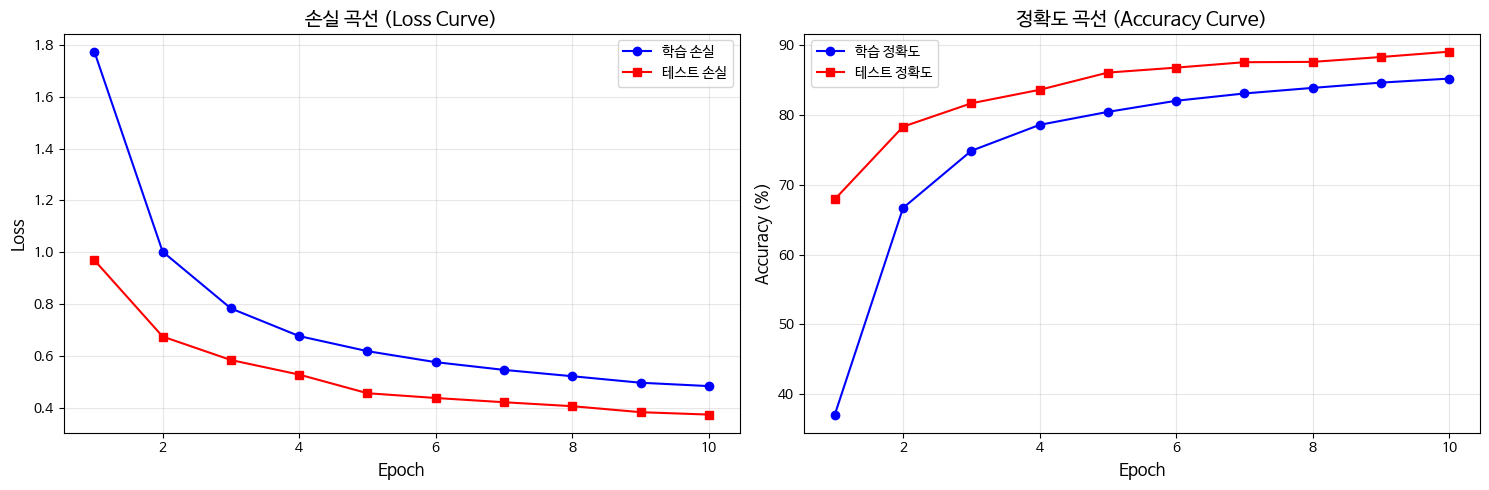


최종 성능 요약:
최종 학습 손실: 0.4840
최종 학습 정확도: 85.20%
최종 테스트 손실: 0.3742
최종 테스트 정확도: 89.06%
최고 테스트 정확도: 89.06%


In [20]:
# 학습 곡선 그리기

# 에폭 번호 (x축)
epochs_range = range(1, num_epochs + 1)

# 2x1 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 왼쪽 그래프: 손실 곡선
ax1.plot(epochs_range, train_losses, 'b-', label='학습 손실', marker='o')
ax1.plot(epochs_range, test_losses, 'r-', label='테스트 손실', marker='s')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('손실 곡선 (Loss Curve)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 오른쪽 그래프: 정확도 곡선
ax2.plot(epochs_range, train_accs, 'b-', label='학습 정확도', marker='o')
ax2.plot(epochs_range, test_accs, 'r-', label='테스트 정확도', marker='s')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('정확도 곡선 (Accuracy Curve)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최종 성능 요약
print('\n최종 성능 요약:')
print('='*60)
print(f'최종 학습 손실: {train_losses[-1]:.4f}')
print(f'최종 학습 정확도: {train_accs[-1]:.2f}%')
print(f'최종 테스트 손실: {test_losses[-1]:.4f}')
print(f'최종 테스트 정확도: {test_accs[-1]:.2f}%')
print(f'최고 테스트 정확도: {best_acc:.2f}%')
print('='*60)

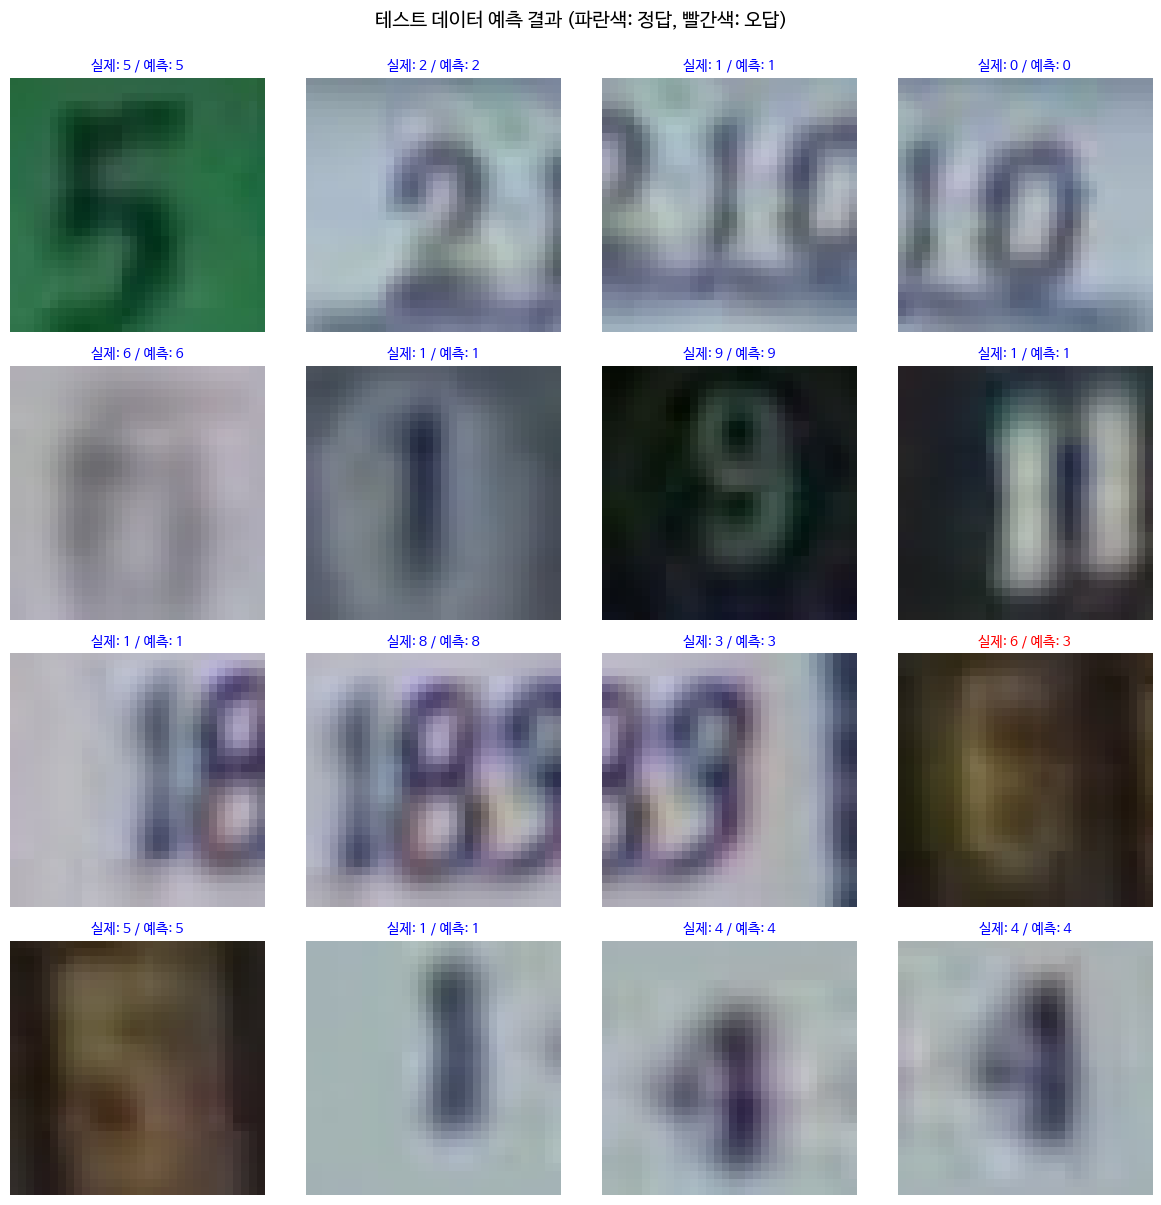


현재 배치 정확도: 90.62% (116/128)


In [21]:
# 예측 결과 시각화
# 테스트 데이터에서 예측 결과 확인

# 최고 성능 모델 로드
model.load_state_dict(torch.load('best_svhn_model.pth'))
# load_state_dict(): 저장된 파라미터를 모델에 로드
model.eval()  # 평가 모드

# 테스트 데이터에서 배치 하나 가져오기
dataiter = iter(test_loader)
images, labels = next(dataiter)

# 모델로 예측
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

# CPU로 이동 및 역정규화
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

# 16개 샘플 시각화
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)

    # 이미지 역정규화 및 차원 변환
    img = denormalize(images[i]).numpy().transpose(1, 2, 0)
    plt.imshow(img)

    # 정답과 예측 표시
    true_label = class_names[labels[i]]
    pred_label = class_names[predicted[i]]

    # 정답이면 파란색, 오답이면 빨간색
    color = 'blue' if true_label == pred_label else 'red'
    plt.title(f'실제: {true_label} / 예측: {pred_label}', color=color, fontsize=10)
    plt.axis('off')

plt.suptitle('테스트 데이터 예측 결과 (파란색: 정답, 빨간색: 오답)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# 정확도 계산
correct = (predicted == labels).sum().item()
total = labels.size(0)
print(f'\n현재 배치 정확도: {100.*correct/total:.2f}% ({correct}/{total})')

혼동 행렬 계산 중: 100%|██████████| 204/204 [00:03<00:00, 56.88it/s]


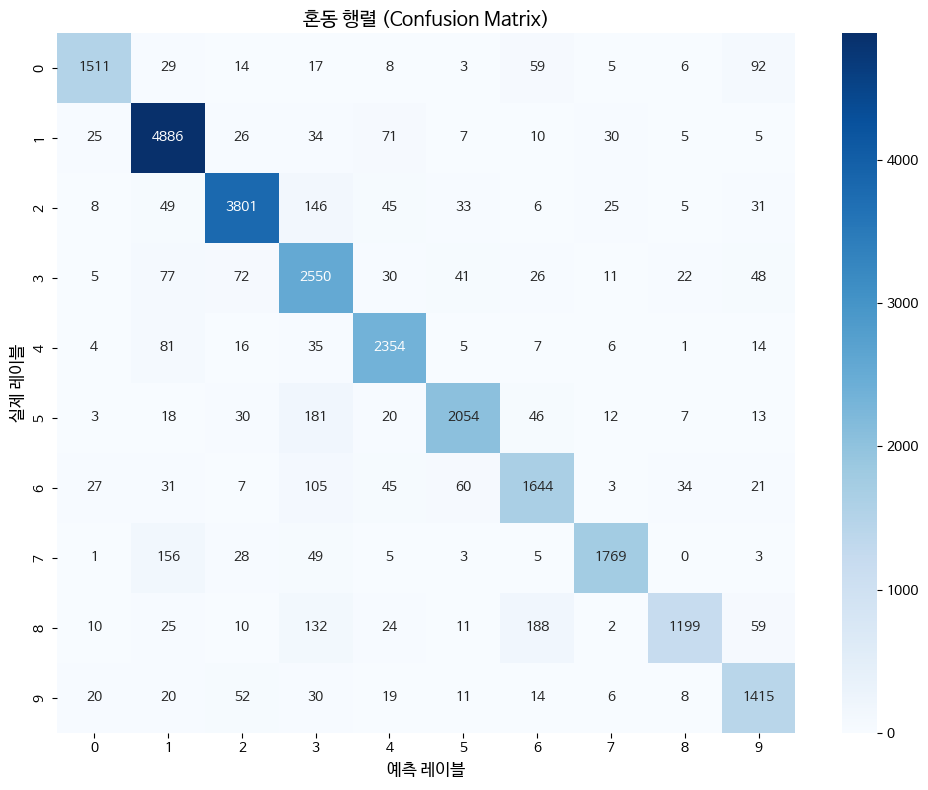


클래스별 정확도:
숫자                     정확도            샘플 수
------------------------------------------------------------
0                   86.64%            1744
1                   95.82%            5099
2                   91.61%            4149
3                   88.48%            2882
4                   93.30%            2523
5                   86.16%            2384
6                   83.16%            1977
7                   87.62%            2019
8                   72.23%            1660
9                   88.71%            1595


In [22]:
# 혼동 행렬 계산 및 시각화
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 전체 테스트 데이터에 대한 예측
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='혼동 행렬 계산 중'):
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# 혼동 행렬 계산
cm = confusion_matrix(all_labels, all_preds)

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('예측 레이블', fontsize=12)
plt.ylabel('실제 레이블', fontsize=12)
plt.title('혼동 행렬 (Confusion Matrix)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 클래스별 정확도 계산
print('\n클래스별 정확도:')
print('='*60)
print(f'{"숫자":<10} {"정확도":>15} {"샘플 수":>15}')
print('-'*60)

for i in range(10):
    # 해당 클래스의 정확도 계산
    class_correct = cm[i, i]  # 대각선 원소 (정답)
    class_total = cm[i].sum()  # 해당 행의 합 (전체)
    class_acc = 100.0 * class_correct / class_total if class_total > 0 else 0
    print(f'{class_names[i]:<10} {class_acc:>14.2f}% {class_total:>15}')

print('='*60)